In [1]:
!wget "https://huggingface.co/datasets/AI-for-Infrastructure-Management/imp-act-benchmark-results/resolve/main/inference_results_ToyExample-v2_Cologne-v1_CologneBonnDusseldorf-v1.csv?download=true" -O "data/inference_results_ToyExample-v2_Cologne-v1_CologneBonnDusseldorf-v1.csv"

--2025-05-16 11:39:13--  https://huggingface.co/datasets/AI-for-Infrastructure-Management/imp-act-benchmark-results/resolve/main/inference_results_ToyExample-v2_Cologne-v1_CologneBonnDusseldorf-v1.csv?download=true
Resolving huggingface.co (huggingface.co)... 108.138.36.25, 108.138.36.37, 108.138.36.21, ...
Connecting to huggingface.co (huggingface.co)|108.138.36.25|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1577984 (1.5M) [text/plain]
Saving to: ‘data/inference_results_ToyExample-v2_Cologne-v1_CologneBonnDusseldorf-v1.csv’

data/inference_resu 100%[===================>]   1.50M  3.72MB/s    in 0.4s    

2025-05-16 11:39:14 (3.72 MB/s) - ‘data/inference_results_ToyExample-v2_Cologne-v1_CologneBonnDusseldorf-v1.csv’ saved [1577984/1577984]



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

In [3]:
# Define baseline heuristic values (absolute values) for each environment
baseline_heuristic_values = {
    "ToyExample-v2": -273.982452 * 1e6,
    "Cologne-v1": -8192.396484 * 1e6,
    "CologneBonnDusseldorf-v1": -33102.484375 * 1e6,
}

def dataframe_to_best_checkpoints(data, env_name):
    """
    This function takes a dataframe and returns the best checkpoints for each algorithm.
    """
    # Get unique algorithms
    algorithms = data['algorithm'].unique()

    runs_per_algorithm = {
        alg: data[data['algorithm'] == alg]['WANDB_RUN_ID'].unique()
        for alg in algorithms
    }

    best_checkpoint_per_algorithm = {
        alg: {
            run: data[data['WANDB_RUN_ID'] == run]['mean'].max()
            for run in runs_per_algorithm[alg]
        }
    
        for alg in algorithms 
    }

    # Normalize the rewards by baseline heuristic results:
    heuristic_score = baseline_heuristic_values[env_name]

    best_checkpoint_per_algorithm_norm = {
        alg: {
            run: (score - heuristic_score) / abs(heuristic_score)
            for run, score in best_checkpoint_per_algorithm[alg].items()
        }
        for alg in algorithms
    }
    return best_checkpoint_per_algorithm_norm

data = pd.read_csv('data/inference_results_ToyExample-v2_Cologne-v1_CologneBonnDusseldorf-v1.csv')

algorithms = data['algorithm'].unique()
environments = data['map_name'].unique()

best_checkpoints = {
    environment: dataframe_to_best_checkpoints(data[data['map_name'] == environment], environment)
    for environment in environments
}

In [4]:
from time import time
np.random.seed(int(time()))
random_seed = 45081 # np.random.randint(0, 100000)
#print(f"Random seed: {random_seed}")
figsize = (5.5, 3.8)
y_lims = (-55, 30)
x_margin = 0.75

print_extra_baseline_heuristics = False

algorithm_names = {
    "vdn_rnn": "VDN",
    "qmix_rnn": "QMIX",
    "pqn_rnn": "PQN-VDN",
    "ippo_rnn": "IPPO",
    "mappo_rnn": "MAPPO",
}

env_plot_titles = {
    "ToyExample-v2": "ToyExample\n(12 agents)",
    "Cologne-v1": "Cologne\n(60 agents)",
    "CologneBonnDusseldorf-v1": "CologneBonnDusseldorf\n(178 agents)",
}

plt.rcParams.update({
    'font.size': 8,
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],  # or 'Times'
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'text.usetex': False,
})

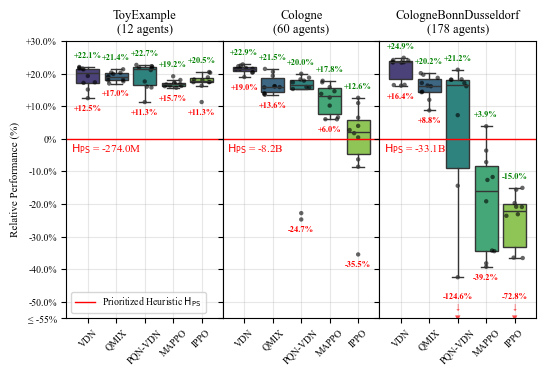

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# (cell content truncated for brevity in this edit – only the specific comment line is updated below)

# ... existing plotting code above ...

# Add horizontal line at 0 (segment-based heuristic baseline)
# (rest of the original cell content remains unchanged)

In [ ]:
# Print all best checkpoints in a table
order = ['vdn_rnn', 'qmix_rnn', 'pqn_rnn', 'mappo_rnn', 'ippo_rnn']
for env in best_checkpoints.keys():
    print(f"Best checkpoints for {env}:")
    # Sort the algorithms by our custom order
    sorted_algorithms = sorted(best_checkpoints[env].keys(), key=lambda x: order.index(x))
    for alg in sorted_algorithms:
        runs = best_checkpoints[env][alg]
        # Sort runs by their values
        sorted_runs = sorted(runs.items(), key=lambda x: x[1], reverse=True)
        # Print the sorted runs
        # compute IQR
        values = np.array(list(runs.values()))
        q75, q25 = np.percentile(values, [75, 25])
        iqr = q75 - q25
        print(f"  {algorithm_names[alg]} & {' & '.join(f'{value*100:+.2f}' for run, value in sorted_runs)}")
        print(f"  IQR: {iqr*100:.2f}")
    print()

Best checkpoints for ToyExample-v2:
  VDN & +22.09 & +21.86 & +21.60 & +21.60 & +21.35 & +19.33 & +17.37 & +17.20 & +15.16 & +12.51
  IQR: 4.36
  QMIX & +21.37 & +20.38 & +20.31 & +19.96 & +19.24 & +18.88 & +18.13 & +18.00 & +17.65 & +17.01
  IQR: 2.19
  PQN-VDN & +22.72 & +22.34 & +22.16 & +21.92 & +21.79 & +21.14 & +17.64 & +16.03 & +15.79 & +11.31
  IQR: 5.67
  MAPPO & +19.22 & +18.10 & +17.25 & +17.17 & +16.84 & +16.70 & +16.36 & +16.26 & +16.19 & +15.70
  IQR: 0.94
  IPPO & +20.54 & +20.32 & +18.90 & +18.24 & +18.03 & +17.48 & +17.43 & +17.42 & +16.32 & +11.32
  IQR: 1.32

Best checkpoints for Cologne-v1:
  VDN & +22.88 & +22.48 & +22.32 & +21.76 & +21.53 & +21.49 & +21.43 & +20.46 & +20.35 & +19.00
  IQR: 1.48
  QMIX & +21.48 & +20.60 & +19.37 & +16.20 & +16.13 & +15.91 & +15.82 & +14.02 & +13.80 & +13.55
  IQR: 4.10
  PQN-VDN & +20.01 & +18.81 & +18.28 & +17.89 & +17.39 & +15.95 & +15.84 & +15.33 & -22.78 & -24.72
  IQR: 2.73
  MAPPO & +17.85 & +17.37 & +15.90 & +14.64 & +13.83 